<a href="https://colab.research.google.com/github/shreyashahane1410-maker/ANNDL_Projects/blob/main/TA02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pandas numpy matplotlib scikit-learn tensorflow kagglehub

In [ ]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten, MaxPooling1D

import kagglehub



In [ ]:

# 2. Download Dataset
path = kagglehub.dataset_download("aakash50897/churn-modellingcsv")
print("Path to dataset files:", path)

# Find CSV file inside downloaded folder
files = os.listdir(path)
print("Files:", files)

# Load dataset (auto-detect CSV)
csv_file = [f for f in files if f.endswith(".csv")][0]
data_path = os.path.join(path, csv_file)

data = pd.read_csv(data_path)

print(data.head())


In [ ]:
# 3. Data Preprocessing
data = data.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Encode categorical
le = LabelEncoder()
data['Gender'] = le.fit_transform(data['Gender'])

data = pd.get_dummies(data, columns=['Geography'], drop_first=True)

X = data.drop('Exited', axis=1)
y = data['Exited']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. ANN Model
ann = Sequential()

ann.add(Dense(16, activation='relu', input_dim=X_train.shape[1]))
ann.add(Dense(8, activation='relu'))
ann.add(Dense(1, activation='sigmoid'))

ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_ann = ann.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7588 - loss: 0.5450 - val_accuracy: 0.8006 - val_loss: 0.4521
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7994 - loss: 0.4543 - val_accuracy: 0.8175 - val_loss: 0.4193
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8075 - loss: 0.4366 - val_accuracy: 0.8269 - val_loss: 0.4097
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8125 - loss: 0.4277 - val_accuracy: 0.8294 - val_loss: 0.4039
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8175 - loss: 0.4190 - val_accuracy: 0.8350 - val_loss: 0.3972
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8244 - loss: 0.4093 - val_accuracy: 0.8394 - val_loss: 0.3895
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8352 - loss: 0.3995 - val_accuracy: 0.8419 - val_loss: 0.3810
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8392 - loss: 0.3892 - val_accuracy: 0.8444 - val_

In [7]:
# 5. ANN Evaluation
y_pred_ann = (ann.predict(X_test) > 0.5)

print("\n===== ANN RESULTS =====")
print("Accuracy:", accuracy_score(y_test, y_pred_ann))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_ann))
print("Report:\n", classification_report(y_test, y_pred_ann))

# 6. CNN Model
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

cnn = Sequential()

cnn.add(Conv1D(filters=32, kernel_size=2, activation='relu',
               input_shape=(X_train.shape[1], 1)))
cnn.add(MaxPooling1D(pool_size=2))
cnn.add(Flatten())
cnn.add(Dense(16, activation='relu'))
cnn.add(Dense(1, activation='sigmoid'))

cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_cnn = cnn.fit(
    X_train_cnn, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

===== ANN RESULTS =====
Accuracy: 0.8595
Confusion Matrix:
 [[1530   77]
 [ 204  189]]
Report:
               precision    recall  f1-score   support

           0       0.88      0.95      0.92      1607
           1       0.71      0.48      0.57       393

    accuracy                           0.86      2000
   macro avg       0.80      0.72      0.74      2000
weighted avg       0.85      0.86      0.85      2000

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7706 - loss: 0.5167 - val_accuracy: 0.8031 - val_loss: 0.4500
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8083 - loss: 0.4468 - val_accuracy: 0.8263 - val_loss: 0.4235
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8200 - loss: 0.4256 - val_accuracy: 0.8350 - val_loss: 0.4096
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8244 - loss: 0.4101 - val_accuracy: 0.8338 - val_loss: 0.3998
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8323 - loss: 0.3982 - val_accuracy: 0.8338 - val_loss: 0.3964
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8363 - loss: 0.3898 - val_accuracy: 0.8381 - val_loss: 0.3847
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8420 - loss: 0.3829 - val_accuracy: 0.8413 - val_loss: 0.3817
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8427 - loss: 0.3788 - val_accuracy: 0.8419 - val_

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

===== CNN RESULTS =====
Accuracy: 0.8595
Confusion Matrix:
 [[1491  116]
 [ 165  228]]
Report:
               precision    recall  f1-score   support

           0       0.90      0.93      0.91      1607
           1       0.66      0.58      0.62       393

    accuracy                           0.86      2000
   macro avg       0.78      0.75      0.77      2000
weighted avg       0.85      0.86      0.86      2000



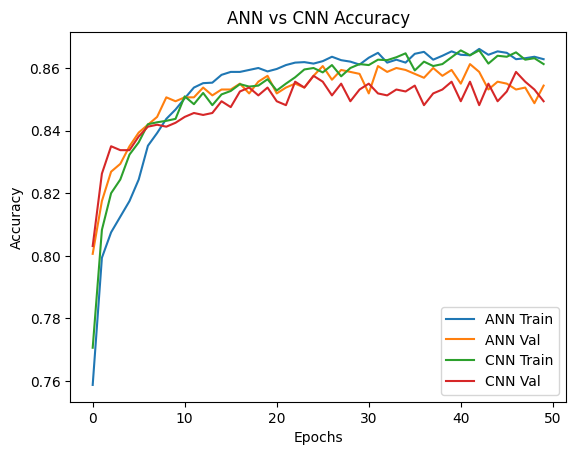

In [8]:
# 7. CNN Evaluation
y_pred_cnn = (cnn.predict(X_test_cnn) > 0.5)

print("\n===== CNN RESULTS =====")
print("Accuracy:", accuracy_score(y_test, y_pred_cnn))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_cnn))
print("Report:\n", classification_report(y_test, y_pred_cnn))

# 8. Accuracy Graph
plt.figure()

plt.plot(history_ann.history['accuracy'], label='ANN Train')
plt.plot(history_ann.history['val_accuracy'], label='ANN Val')

plt.plot(history_cnn.history['accuracy'], label='CNN Train')
plt.plot(history_cnn.history['val_accuracy'], label='CNN Val')

plt.title("ANN vs CNN Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()


In [9]:

# 9. Final Comparison
ann_acc = accuracy_score(y_test, y_pred_ann)
cnn_acc = accuracy_score(y_test, y_pred_cnn)

print("\n===== FINAL COMPARISON =====")
print("ANN Accuracy:", ann_acc)
print("CNN Accuracy:", cnn_acc)


===== FINAL COMPARISON =====
ANN Accuracy: 0.8595
CNN Accuracy: 0.8595
